# 2025/26 Big Five striker shot profiles

## Goal
Compare shot frequency, chance quality and observed conversion. This is a clone-coding tutorial using a saved Understat snapshot, not a player-quality or recruitment model.

## Setup
Run from inside this package. Install `requirements.txt`, select the Python kernel and run all cells in order. Each run creates a new results folder.

## Assumptions
One row is player × league × season. Candidates have at least 900 league minutes and pass the saved source checks. Counts include all positions played. Non-penalty shots include non-penalty set pieces. Team context, league strength and game state are not adjusted.

Source: [Understat](https://understat.com/), snapshot saved 2026-10-03. Input paths and SHA-256 hashes are in `data/input_manifest.json`.

## Steps

### 1. Setup and parameters

Set paths and parameters once. The source snapshot is preserved. Each run writes to a new results folder.

In [1]:
%matplotlib inline
from pathlib import Path
from datetime import datetime, timezone
import json
import hashlib
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.ticker import PercentFormatter

LANGUAGE = "en"
MIN_MINUTES = 900
REP_MIN_SHOTS = 50
LEAGUES = ["EPL", "La_liga", "Bundesliga", "Serie_A", "Ligue_1"]
COLORS = dict(zip(LEAGUES, ["#2864A0", "#D99600", "#713EB8", "#778346", "#B7638B"]))
MARKERS = dict(zip(LEAGUES, ["o", "s", "^", "D", "v"]))

start = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
ROOT = next((p for p in [start, *start.parents] if (p / "data/input_manifest.json").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Open this notebook from inside the striker-analysis folder.")
DATA = ROOT / "data/input"
run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUTPUT = ROOT / "results" / LANGUAGE / run_id
OUTPUT.mkdir(parents=True, exist_ok=False)

def text(en, ko):
    return ko if LANGUAGE == "ko" else en

plt.rcParams.update({"font.size": 12, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.unicode_minus": False, "savefig.facecolor": "white"})
if LANGUAGE == "ko":
    available = {font.name for font in font_manager.fontManager.ttflist}
    font = next((name for name in ["AppleGothic", "Apple SD Gothic Neo", "Malgun Gothic", "Noto Sans CJK KR", "NanumGothic"] if name in available), None)
    if font is None:
        raise RuntimeError("Install a Korean font (e.g. Noto Sans CJK KR), then restart the kernel.")
    plt.rcParams["font.family"] = font

def save_chart(fig, name):
    """Save slide-ready PNG and vector SVG, then display the chart."""
    fig.savefig(OUTPUT / f"{name}.png", dpi=180, bbox_inches="tight")
    fig.savefig(OUTPUT / f"{name}.svg", bbox_inches="tight")
    if plt.get_backend().lower() != "agg":
        plt.show()
    plt.close(fig)

print(text("Results folder:", "결과 폴더:"), OUTPUT)


Results folder: football/big-five-striker-profiles/analysis/results/en/20261004T165302398283Z


### 2. Load and inspect data

One profile row means player × league × season. Preview only the columns needed for this analysis.

In [2]:
profiles = pd.read_csv(DATA / "striker_scatter_ready.csv", encoding="utf-8-sig")
shots = pd.read_csv(DATA / "shot_events.csv", encoding="utf-8-sig")
appearances = pd.read_csv(DATA / "player_match_records.csv", encoding="utf-8-sig")
audit = pd.read_csv(DATA / "forward_candidate_audit.csv", encoding="utf-8-sig")
KEY = ["league", "season", "player_id"]
metrics = ["npshots_per90", "npxg_per_shot", "npxg_per90"]
print(text("Rows and columns:", "행·열 수:"), profiles.shape)
print(profiles[["player_name", "league", "team", "minutes", *metrics]].head().to_string(index=False))
print(profiles[["minutes", "non_penalty_shots", *metrics]].dtypes)
print(text("Missing values:", "주요 컬럼 결측치:"), profiles[[*KEY, "player_name", "minutes", "non_penalty_shots", *metrics]].isna().sum().to_dict())

Rows and columns: (181, 43)
           player_name     league                team  minutes  npshots_per90  npxg_per_shot  npxg_per90
        Fisnik Asllani Bundesliga          Hoffenheim     2429       2.704817       0.130203    0.352176
Ransford Königsdörffer Bundesliga        Hamburger SV     2425       2.375258       0.114691    0.272420
       Haris Tabakovic Bundesliga Borussia M.Gladbach     2424       2.413366       0.197289    0.476130
            Harry Kane Bundesliga       Bayern Munich     2385       4.075472       0.196708    0.801677
       Serhou Guirassy Bundesliga   Borussia Dortmund     2366       3.081150       0.217751    0.670924
minutes                int64
non_penalty_shots      int64
npshots_per90        float64
npxg_per_shot        float64
npxg_per90           float64
dtype: object
Missing values: {'league': 0, 'season': 0, 'player_id': 0, 'player_name': 0, 'minutes': 0, 'non_penalty_shots': 0, 'npshots_per90': 0, 'npxg_per_shot': 0, 'npxg_per90': 0}


### 3. Validate the cohort and joins

Validate key uniqueness, scope, metric formulas and event-to-appearance links before making charts. Stop on disagreement.

In [3]:
assert not profiles.duplicated(KEY).any()
assert not shots.duplicated("id").any()
assert not appearances.duplicated([*KEY, "id"]).any()
for frame in [profiles, shots, appearances, audit]:
    assert set(frame["season"]) == {2025}
    assert set(frame["league"]).issubset(set(LEAGUES))
assert set(profiles["league"]) == set(LEAGUES)
assert profiles[[*KEY, "player_name", "minutes", "non_penalty_shots", *metrics]].notna().all().all()
assert profiles["minutes"].ge(MIN_MINUTES).all()
assert profiles["non_penalty_shots"].gt(0).all()
assert profiles["qc_pass"].eq(True).all()
assert profiles["no_source_duplicate_appearances"].eq(True).all()
assert shots[["X", "Y", "xG"]].notna().all().all()
assert shots[["X", "Y", "xG"]].ge(0).all().all() and shots[["X", "Y", "xG"]].le(1).all().all()
assert np.allclose(profiles.npshots_per90, profiles.non_penalty_shots / profiles.minutes * 90)
assert np.allclose(profiles.npxg_per_shot, profiles.shot_sum_npxg / profiles.non_penalty_shots)
assert np.allclose(profiles.npxg_per90, profiles.npshots_per90 * profiles.npxg_per_shot)

# Select cohort records with a many-to-one join: many events, one profile per key.
member_keys = profiles[KEY]
cohort_shots = shots.merge(member_keys, on=KEY, how="inner", validate="many_to_one")
cohort_matches = appearances.merge(member_keys, on=KEY, how="inner", validate="many_to_one")
assert len(cohort_shots) <= len(shots) and len(cohort_matches) <= len(appearances)
assert not cohort_matches.duplicated([*KEY, "id"]).any()
linked = cohort_shots.merge(cohort_matches[[*KEY, "id"]].rename(columns={"id": "match_id"}),
                            on=[*KEY, "match_id"], how="left", validate="many_to_one", indicator=True)
assert len(linked) == len(cohort_shots) and linked["_merge"].eq("both").all()

# Exclude all penalties and OwnGoal events, regardless of penalty success.
np_shots = cohort_shots.loc[cohort_shots["situation"].ne("Penalty") & cohort_shots["result"].ne("OwnGoal")].copy()
event_totals = np_shots.groupby(KEY).agg(event_shots=("id", "size"), event_npxg=("xG", "sum"),
                                       event_goals=("result", lambda values: values.eq("Goal").sum())).reset_index()
match_totals = cohort_matches.groupby(KEY).agg(match_count=("id", "size"), match_minutes=("time", "sum")).reset_index()
reconciled = profiles.merge(event_totals, on=KEY, validate="one_to_one").merge(match_totals, on=KEY, validate="one_to_one")
assert len(reconciled) == len(profiles)
assert (reconciled.non_penalty_shots == reconciled.event_shots).all()
assert (reconciled.non_penalty_goals == reconciled.event_goals).all()
assert (reconciled.appearances == reconciled.match_count).all()
assert (reconciled.minutes == reconciled.match_minutes).all()
assert np.allclose(reconciled.shot_sum_npxg, reconciled.event_npxg, atol=1e-8, rtol=0)
assert np.allclose(reconciled.npxg, reconciled.event_npxg, atol=1e-4, rtol=0)
print(text("Validated profiles, matches, all shot events, non-penalty attempts:", "검증된 선수·출전 기록·전체 이벤트·비페널티 슈팅:"),
      len(profiles), len(cohort_matches), len(cohort_shots), len(np_shots))

Validated profiles, matches, all shot events, non-penalty attempts: 181 5204 9087 8847


### 4. Calculate metrics and profile groups

Keep expected conversion and actual conversion on the same percentage scale. Median-based groups describe this cohort only.

In [4]:
profiles["conversion_pct"] = profiles.non_penalty_goals / profiles.non_penalty_shots * 100
profiles["expected_conversion_pct"] = profiles.npxg_per_shot * 100
profiles["goals_minus_npxg"] = profiles.non_penalty_goals - profiles.shot_sum_npxg
profiles["conversion_gap_pp"] = profiles.conversion_pct - profiles.expected_conversion_pct
assert profiles.conversion_pct.between(0, 100).all()
median_volume = profiles.npshots_per90.median()
median_quality = profiles.npxg_per_shot.median()
profiles["profile_group"] = np.select(
    [profiles.npshots_per90.ge(median_volume) & profiles.npxg_per_shot.ge(median_quality),
     profiles.npshots_per90.ge(median_volume) & profiles.npxg_per_shot.lt(median_quality),
     profiles.npshots_per90.lt(median_volume) & profiles.npxg_per_shot.ge(median_quality)],
    ["high_volume_high_quality", "high_volume_low_quality", "low_volume_high_quality"],
    default="low_volume_low_quality")
for metric in [*metrics, "conversion_pct"]:
    profiles[f"{metric}_league_percentile"] = profiles.groupby("league")[metric].rank(method="average", pct=True) * 100
summary = profiles.groupby("league").agg(players=("player_id", "size"), minutes=("minutes", "sum"),
    np_shots=("non_penalty_shots", "sum"), np_goals=("non_penalty_goals", "sum"), npxg=("shot_sum_npxg", "sum"),
    median_shots_per90=("npshots_per90", "median"), median_xg_per_shot=("npxg_per_shot", "median")).reindex(LEAGUES)
# Use pooled numerators and denominators; do not average player conversion rates.
summary["pooled_conversion_pct"] = summary.np_goals / summary.np_shots * 100
summary["pooled_xg_per_shot"] = summary.npxg / summary.np_shots
print(summary.round(3).to_string())
print(profiles.groupby("profile_group").size().to_string())

            players  minutes  np_shots  np_goals     npxg  median_shots_per90  median_xg_per_shot  pooled_conversion_pct  pooled_xg_per_shot
league                                                                                                                                      
EPL              33    60910      1612       245  299.389               2.387               0.184                 15.199               0.186
La_liga          38    69812      2047       293  324.411               2.582               0.149                 14.314               0.158
Bundesliga       30    50536      1497       234  267.903               2.485               0.166                 15.631               0.179
Serie_A          50    84059      2366       273  344.895               2.465               0.141                 11.538               0.146
Ligue_1          30    49283      1325       193  213.559               2.426               0.158                 14.566               0.161
profile_group

### 5. Shot frequency and chance quality

League color and marker shape identify groups. Dashed lines show player medians, not a quality threshold.

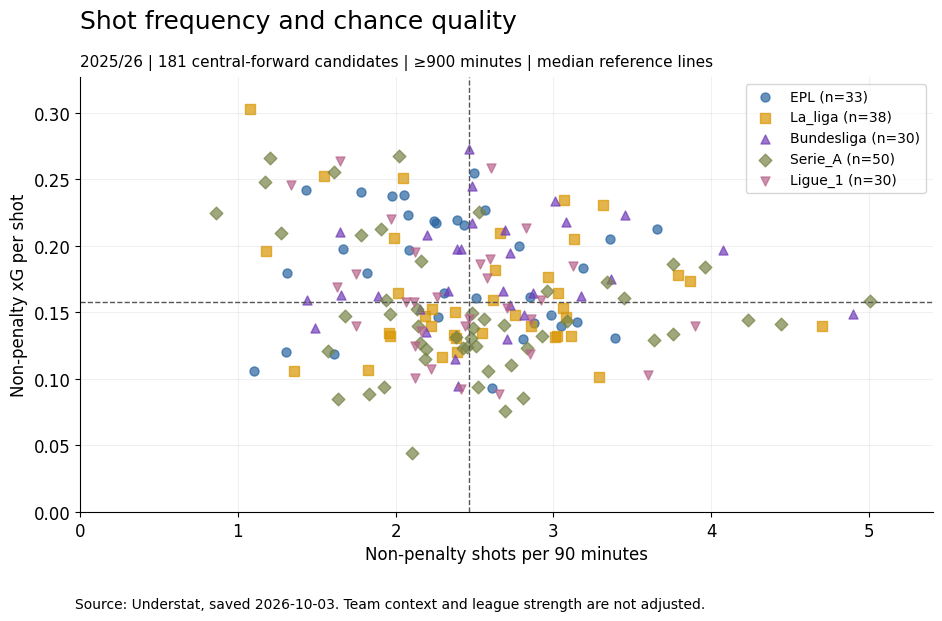

In [5]:
fig, ax = plt.subplots(figsize=(11, 6.4))
for league in LEAGUES:
    group = profiles.loc[profiles.league.eq(league)]
    ax.scatter(group.npshots_per90, group.npxg_per_shot, color=COLORS[league], marker=MARKERS[league],
               s=42, alpha=0.7, label=f"{league} (n={len(group)})")
ax.axvline(median_volume, color="#555555", ls="--", lw=1)
ax.axhline(median_quality, color="#555555", ls="--", lw=1)
ax.set(xlabel=text("Non-penalty shots per 90 minutes", "90분당 비페널티 슈팅 수"),
       ylabel=text("Non-penalty xG per shot", "비페널티 슈팅당 xG"), xlim=(0, profiles.npshots_per90.max()*1.08),
       ylim=(0, profiles.npxg_per_shot.max()*1.08))
ax.set_title(text("Shot frequency and chance quality", "슈팅 빈도와 평균 기회 품질"), loc="left", fontsize=18, pad=35)
ax.text(0, 1.025, text(f"2025/26 | {len(profiles)} central-forward candidates | ≥900 minutes | median reference lines",
                     f"2025/26 · 중앙 공격수 후보 {len(profiles)}명 · 900분 이상 · 점선: 대상 중앙값"), transform=ax.transAxes, fontsize=11)
ax.legend(fontsize=10, loc="upper right")
ax.grid(alpha=0.18)
fig.text(0.12, 0.01, text("Source: Understat, saved 2026-10-03. Team context and league strength are not adjusted.",
                         "출처: Understat, 2026-10-03 저장본. 팀 맥락과 리그 수준은 보정하지 않았습니다."), fontsize=10)
fig.subplots_adjust(bottom=0.16, top=0.84)
save_chart(fig, "01_shot_frequency_quality")

### 6. Expected and observed conversion

The diagonal compares observed goals per shot with average xG. Shot volume remains available in the profile table.

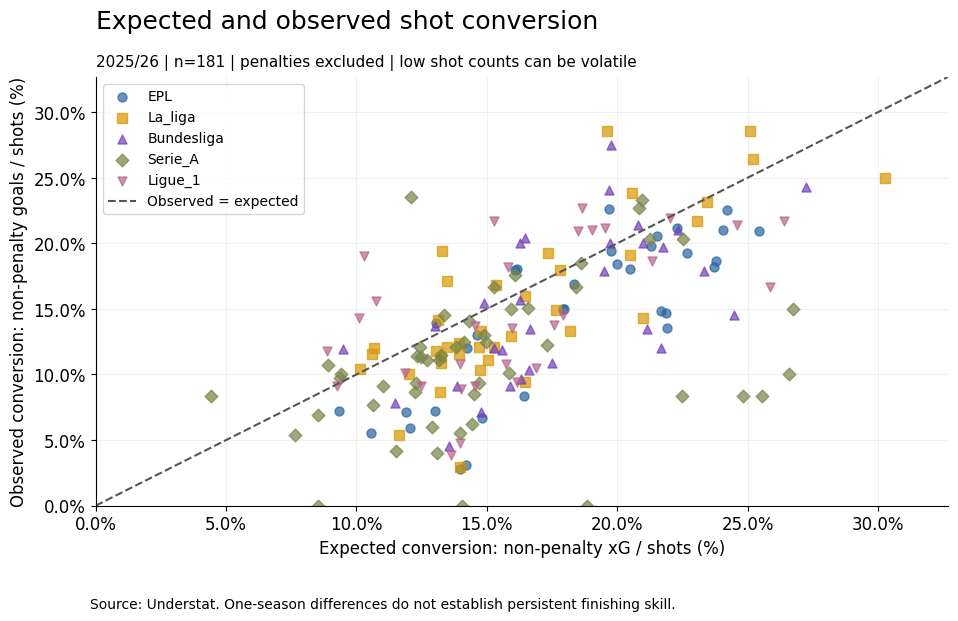

In [6]:
fig, ax = plt.subplots(figsize=(11, 6.4))
for league in LEAGUES:
    group = profiles.loc[profiles.league.eq(league)]
    ax.scatter(group.expected_conversion_pct, group.conversion_pct, color=COLORS[league],
               marker=MARKERS[league], alpha=0.7, s=42, label=league)
upper = max(profiles.expected_conversion_pct.max(), profiles.conversion_pct.max()) * 1.08
ax.plot([0, upper], [0, upper], color="#555555", ls="--", label=text("Observed = expected", "실제 = 기대"))
ax.set(xlim=(0, upper), ylim=(0, upper),
       xlabel=text("Expected conversion: non-penalty xG / shots (%)", "기대 전환율: 비페널티 xG / 슈팅 (%)"),
       ylabel=text("Observed conversion: non-penalty goals / shots (%)", "실제 전환율: 비페널티 득점 / 슈팅 (%)"))
ax.xaxis.set_major_formatter(PercentFormatter(100))
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.set_title(text("Expected and observed shot conversion", "기대 전환율과 실제 득점 전환율"), loc="left", fontsize=18, pad=35)
ax.text(0, 1.025, text(f"2025/26 | n={len(profiles)} | penalties excluded | low shot counts can be volatile",
                     f"2025/26 · {len(profiles)}명 · 페널티 제외 · 슈팅이 적으면 비율 변동이 큽니다"), transform=ax.transAxes, fontsize=11)
ax.legend(fontsize=10); ax.grid(alpha=0.18)
fig.text(0.12, 0.01, text("Source: Understat. One-season differences do not establish persistent finishing skill.",
                         "출처: Understat. 한 시즌 차이로 지속적인 마무리 능력을 확정할 수 없습니다."), fontsize=10)
fig.subplots_adjust(bottom=0.17, top=0.84)
save_chart(fig, "02_expected_observed_conversion")

### 7. League distributions

Show medians and spread rather than treating different leagues as identical contexts. Comparisons cover selected candidates only.

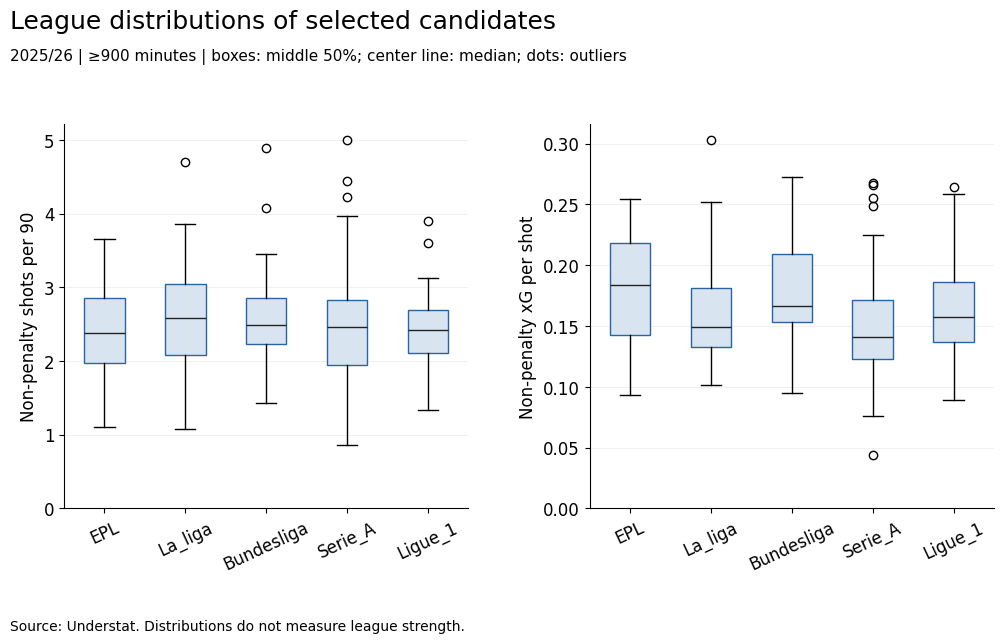

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6.4))
for ax, metric, label in zip(axes, ["npshots_per90", "npxg_per_shot"],
    [text("Non-penalty shots per 90", "90분당 비페널티 슈팅"), text("Non-penalty xG per shot", "비페널티 슈팅당 xG")]):
    distributions = [profiles.loc[profiles.league.eq(league), metric] for league in LEAGUES]
    boxes = ax.boxplot(distributions, tick_labels=LEAGUES, patch_artist=True, medianprops={"color": "#222222"})
    for patch in boxes["boxes"]:
        patch.set_facecolor("#D8E5F1"); patch.set_edgecolor("#2864A0")
    ax.set_ylabel(label); ax.tick_params(axis="x", rotation=25)
    ax.set_ylim(bottom=0); ax.grid(axis="y", alpha=0.18)
fig.suptitle(text("League distributions of selected candidates", "선정된 공격수 후보의 리그별 지표 분포"), fontsize=18, x=0.08, ha="left")
fig.text(0.08, 0.9, text("2025/26 | ≥900 minutes | boxes: middle 50%; center line: median; dots: outliers",
                         "2025/26 · 900분 이상 · 상자: 가운데 50% · 중앙선: 중앙값 · 점: 이상치"), fontsize=11)
fig.text(0.08, 0.01, text("Source: Understat. Distributions do not measure league strength.", "출처: Understat. 이 분포로 리그 수준을 평가할 수 없습니다."), fontsize=10)
fig.subplots_adjust(bottom=0.2, top=0.8, wspace=0.3)
save_chart(fig, "03_league_distributions")

### 8. Select contrasting examples

For each non-empty quadrant, select the ≥50-shot player closest to that quadrant’s median profile after scaling by cohort standard deviations. These are illustrative cases, not rankings.

In [8]:
representative_rows = []
scale = profiles[["npshots_per90", "npxg_per_shot"]].std().replace(0, 1)
for group_name, group in profiles.groupby("profile_group", sort=True):
    eligible = group.loc[group.non_penalty_shots.ge(REP_MIN_SHOTS)].copy()
    if eligible.empty:
        continue
    center = group[["npshots_per90", "npxg_per_shot"]].median()
    eligible["distance_to_group_median"] = (((eligible[["npshots_per90", "npxg_per_shot"]] - center) / scale)**2).sum(axis=1)
    chosen = eligible.sort_values(["distance_to_group_median", "player_id", "league"]).iloc[0]
    representative_rows.append(chosen)
representatives = pd.DataFrame(representative_rows)
assert not representatives.empty
comparison_columns = ["player_name", "league", "team", "profile_group", "minutes", "non_penalty_shots",
    "non_penalty_goals", "npshots_per90", "npxg_per_shot", "conversion_pct", "goals_minus_npxg"]
print(representatives[comparison_columns].round(3).to_string(index=False))

     player_name  league              team            profile_group  minutes  non_penalty_shots  non_penalty_goals  npshots_per90  npxg_per_shot  conversion_pct  goals_minus_npxg
    Hugo Ekitike     EPL         Liverpool high_volume_high_quality     1835                 65                 11          3.188          0.184          16.923            -0.932
    Ante Budimir La_liga           Osasuna  high_volume_low_quality     2995                 95                 11          2.855          0.139          11.579            -2.246
  Rasmus Højlund Serie_A            Napoli  low_volume_high_quality     2784                 59                 12          1.907          0.213          20.339            -0.551
Mateo Pellegrino Serie_A Parma Calcio 1913   low_volume_low_quality     3012                 72                  8          2.151          0.127          11.111            -1.149


### 9. Shot locations and shot composition

Plot saved normalized coordinates without assuming physical pitch dimensions. Keep all attempts and highlight goals. Compare shot types and situations separately.

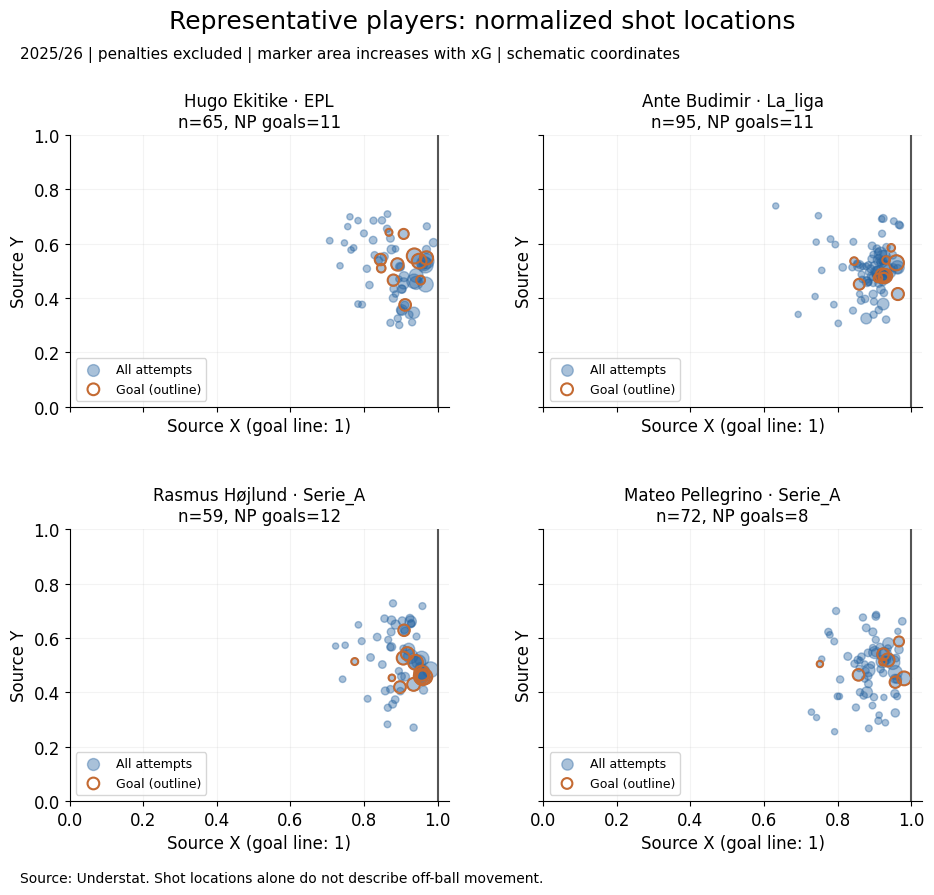

          player      shotType  shots  shot_share_pct  xg_per_shot
    Hugo Ekitike          Head     13          20.000        0.332
    Hugo Ekitike      LeftFoot      8          12.308        0.214
    Hugo Ekitike OtherBodyPart      1           1.538        0.135
    Hugo Ekitike     RightFoot     43          66.154        0.134
    Ante Budimir          Head     40          42.105        0.135
    Ante Budimir      LeftFoot     43          45.263        0.144
    Ante Budimir OtherBodyPart      1           1.053        0.019
    Ante Budimir     RightFoot     11          11.579        0.148
  Rasmus Højlund          Head      9          15.254        0.256
  Rasmus Højlund      LeftFoot     30          50.847        0.219
  Rasmus Højlund     RightFoot     20          33.898        0.184
Mateo Pellegrino          Head     30          41.667        0.166
Mateo Pellegrino      LeftFoot     34          47.222        0.108
Mateo Pellegrino     RightFoot      8          11.111        0

In [9]:
example_shots = np_shots.merge(representatives[KEY], on=KEY, how="inner", validate="many_to_one")
composition_tables = []
for dimension in ["shotType", "situation"]:
    composition = example_shots.groupby([*KEY, "player", dimension]).agg(shots=("id", "size"),
        npxg=("xG", "sum"), goals=("result", lambda values: values.eq("Goal").sum())).reset_index()
    composition["shot_share_pct"] = composition.shots / composition.groupby(KEY).shots.transform("sum") * 100
    composition["xg_per_shot"] = composition.npxg / composition.shots
    assert np.allclose(composition.groupby(KEY).shot_share_pct.sum(), 100)
    composition.to_csv(OUTPUT / f"composition_{dimension}.csv", index=False, encoding="utf-8-sig")
    composition_tables.append(composition)
fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)
for ax, (_, player) in zip(axes.flat, representatives.iterrows()):
    events = example_shots.loc[example_shots.player_id.eq(player.player_id) & example_shots.league.eq(player.league)]
    goals = events.loc[events.result.eq("Goal")]
    ax.scatter(events.X, events.Y, s=18+events.xG*150, color="#2864A0", alpha=0.4,
               label=text("All attempts", "전체 슈팅"))
    ax.scatter(goals.X, goals.Y, s=18+goals.xG*150, facecolors="none", edgecolors="#C46A32", linewidths=1.5,
               label=text("Goal (outline)", "득점 (테두리)"))
    ax.axvline(1, color="#555555", lw=1.5)
    ax.set(xlim=(0, 1.03), ylim=(0, 1), xlabel=text("Source X (goal line: 1)", "원천 X (공격 골라인: 1)"),
           ylabel=text("Source Y", "원천 Y"))
    ax.set_title(f"{player.player_name} · {player.league}\nn={len(events)}, {text('NP goals', '비페널티 득점')}={len(goals)}", fontsize=12)
    ax.grid(alpha=0.15); ax.legend(fontsize=9, loc="lower left")
for ax in list(axes.flat)[len(representatives):]:
    ax.set_visible(False)
fig.suptitle(text("Representative players: normalized shot locations", "대표 선수의 슈팅 위치: 원천 정규화 좌표"), fontsize=18)
fig.text(0.08, 0.925, text("2025/26 | penalties excluded | marker area increases with xG | schematic coordinates",
                          "2025/26 · 페널티 제외 · 점 크기는 xG에 따라 증가 · 실제 거리 단위가 아닙니다"), fontsize=11)
fig.text(0.08, 0.01, text("Source: Understat. Shot locations alone do not describe off-ball movement.",
                         "출처: Understat. 슈팅 위치만으로 오프더볼 움직임을 설명할 수 없습니다."), fontsize=10)
fig.subplots_adjust(top=0.84, bottom=0.1, hspace=0.45, wspace=0.25)
save_chart(fig, "04_representative_shot_locations")
print(composition_tables[0][["player", "shotType", "shots", "shot_share_pct", "xg_per_shot"]].round(3).to_string(index=False))

### 10. Match-level consistency

Start from every appearance, then attach event totals. A verified appearance without an eligible shot becomes zero, not a missing match. Rates use minutes played.

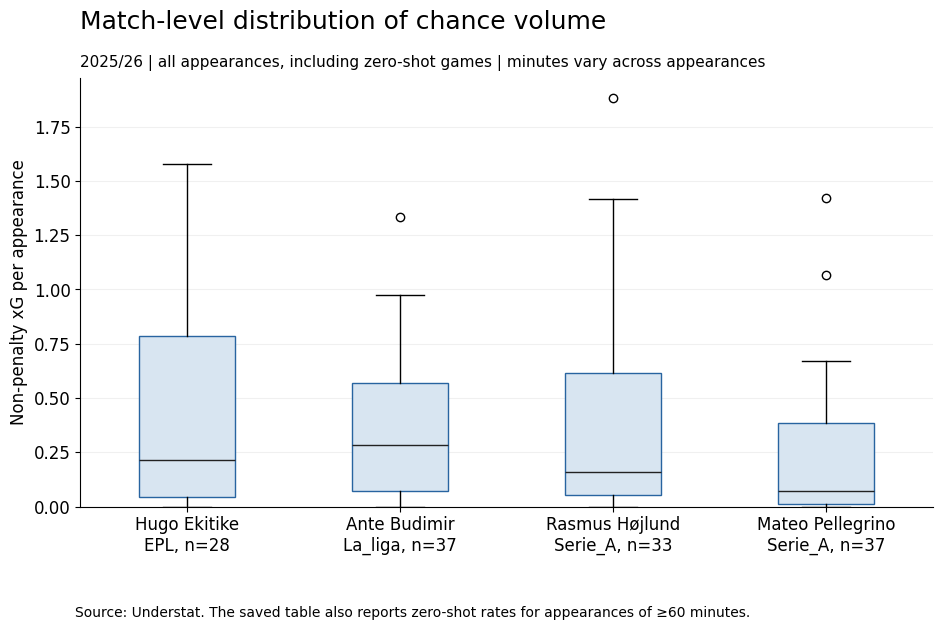

 league  season  player_id  matches  no_np_shot_matches  median_match_npxg  match_npxg_q25  match_npxg_q75  no_np_shot_match_pct      player_name  minutes  matches_60plus  no_np_shot_60plus  no_np_shot_60plus_pct
    EPL    2025       8995       28                   6              0.215           0.044           0.784                21.429     Hugo Ekitike     1835              20                  3                 15.000
La_liga    2025       1235       37                   4              0.283           0.071           0.569                10.811     Ante Budimir     2995              35                  2                  5.714
Serie_A    2025      11055       33                   4              0.159           0.055           0.615                12.121   Rasmus Højlund     2784              32                  3                  9.375
Serie_A    2025      13446       37                   9              0.070           0.012           0.385                24.324 Mateo Pellegrino   

In [10]:
match_events = np_shots.groupby([*KEY, "match_id"]).agg(np_shots=("id", "size"), np_xg=("xG", "sum")).reset_index()
match_profiles = cohort_matches.rename(columns={"id": "match_id"}).merge(match_events,
    on=[*KEY, "match_id"], how="left", validate="one_to_one")
assert len(match_profiles) == len(cohort_matches)
match_profiles[["np_shots", "np_xg"]] = match_profiles[["np_shots", "np_xg"]].fillna(0)
match_profiles["np_shots"] = match_profiles.np_shots.astype(int)
assert match_profiles.time.gt(0).all()
match_profiles["np_xg_per90"] = match_profiles.np_xg / match_profiles.time * 90
match_profiles["no_np_shot"] = match_profiles.np_shots.eq(0)
consistency = match_profiles.groupby(KEY).agg(matches=("match_id", "size"),
    no_np_shot_matches=("no_np_shot", "sum"), median_match_npxg=("np_xg", "median"),
    match_npxg_q25=("np_xg", lambda values: values.quantile(0.25)),
    match_npxg_q75=("np_xg", lambda values: values.quantile(0.75))).reset_index()
consistency["no_np_shot_match_pct"] = consistency.no_np_shot_matches / consistency.matches * 100
consistency = consistency.merge(profiles[[*KEY, "player_name", "minutes"]], on=KEY, validate="one_to_one")
long_appearances = match_profiles.loc[match_profiles.time.ge(60)]
long_summary = long_appearances.groupby(KEY).agg(matches_60plus=("match_id", "size"),
    no_np_shot_60plus=("no_np_shot", "sum")).reset_index()
long_summary["no_np_shot_60plus_pct"] = long_summary.no_np_shot_60plus / long_summary.matches_60plus * 100
consistency = consistency.merge(long_summary, on=KEY, how="left", validate="one_to_one")
assert match_profiles.np_shots.sum() == len(np_shots)
assert np.isclose(match_profiles.np_xg.sum(), np_shots.xG.sum())
example_matches = match_profiles.merge(representatives[KEY], on=KEY, validate="many_to_one")
fig, ax = plt.subplots(figsize=(11, 6.5))
values, names = [], []
for _, player in representatives.iterrows():
    group = example_matches.loc[example_matches.player_id.eq(player.player_id) & example_matches.league.eq(player.league)]
    values.append(group.np_xg)
    names.append(f"{player.player_name}\n{player.league}, n={len(group)}")
boxes = ax.boxplot(values, tick_labels=names, patch_artist=True, medianprops={"color": "#222222"})
for patch in boxes["boxes"]:
    patch.set_facecolor("#D8E5F1"); patch.set_edgecolor("#2864A0")
ax.set_ylabel(text("Non-penalty xG per appearance", "出場1試合あたり非PK xG").replace("出場1試合あたり非PK xG", "출전 경기당 비페널티 xG"))
ax.set_ylim(bottom=0); ax.grid(axis="y", alpha=0.18)
ax.set_title(text("Match-level distribution of chance volume", "경기별 비페널티 기대득점 분포"), loc="left", fontsize=18, pad=35)
ax.text(0, 1.025, text("2025/26 | all appearances, including zero-shot games | minutes vary across appearances",
                     "2025/26 · 무슈팅 경기를 포함한 전체 출전 · 경기별 출전시간은 다릅니다"), transform=ax.transAxes, fontsize=11)
fig.text(0.12, 0.01, text("Source: Understat. The saved table also reports zero-shot rates for appearances of ≥60 minutes.",
                         "출처: Understat. 비교표에는 60분 이상 출전 경기의 무슈팅 비율도 제공합니다."), fontsize=10)
fig.subplots_adjust(bottom=0.18, top=0.84)
save_chart(fig, "05_match_consistency")
print(consistency.merge(representatives[KEY], on=KEY, validate="one_to_one").round(3).to_string(index=False))

### 11. Sensitivity to minimum minutes

Rebuild cohorts from the complete candidate audit, not the prefiltered 181 rows. Keep role and quality checks fixed.

In [11]:
sensitivity_rows = []
for threshold in [600, 900, 1200, 1500]:
    sample = audit.loc[audit.role_classification.eq("central_forward_candidate") & audit.qc_pass.eq(True)
                       & audit.minutes.ge(threshold) & audit.non_penalty_shots.gt(0)]
    sensitivity_rows.append({"min_minutes": threshold, "player_league_rows": len(sample),
        "unique_players": sample.player_id.nunique(), "median_shots_per90": sample.npshots_per90.median(),
        "median_xg_per_shot": sample.npxg_per_shot.median()})
    if threshold == MIN_MINUTES:
        assert set(map(tuple, sample[KEY].to_numpy())) == set(map(tuple, profiles[KEY].to_numpy()))
sensitivity = pd.DataFrame(sensitivity_rows)
print(sensitivity.round(3).to_string(index=False))

 min_minutes  player_league_rows  unique_players  median_shots_per90  median_xg_per_shot
         600                 210             207               2.484               0.157
         900                 181             181               2.465               0.158
        1200                 136             136               2.500               0.159
        1500                 107             107               2.520               0.159


### 12. Metric leaders and players strong on both measures

In [12]:
# Rank each metric separately. Keep tied ranks, use unrounded values, and never call these overall ability rankings.
STANDOUT_MIN_SHOTS = 50
TOP_N = 10
STANDOUT_QUANTILE = 0.75
rank_columns = [*KEY, "player_name", "team", "minutes", "non_penalty_shots", "non_penalty_goals",
                "shot_sum_npxg", "npshots_per90", "npxg_per_shot", "conversion_pct", "goals_minus_npxg"]
eligible = profiles.loc[profiles.non_penalty_shots.ge(STANDOUT_MIN_SHOTS)].copy()

def rank_metric(frame, metric):
    """Rank one metric, retaining equal values at the same rank. Display order for ties uses the player key."""
    ranked = frame[rank_columns].copy()
    ranked["metric_rank"] = ranked[metric].rank(method="min", ascending=False).astype(int)
    ranked["ranking_metric"] = metric
    ranked["minimum_np_shots"] = 1 if metric == "npshots_per90" else STANDOUT_MIN_SHOTS
    ranked = ranked.sort_values([metric, *KEY], ascending=[False, True, True, True]).reset_index(drop=True)
    assert ranked[metric].is_monotonic_decreasing
    assert not ranked.duplicated(KEY).any()
    return ranked

volume_ranking = rank_metric(profiles, "npshots_per90")
quality_ranking = rank_metric(eligible, "npxg_per_shot")
finishing_ranking = rank_metric(eligible, "goals_minus_npxg")
# Quartile thresholds use all 181 cohort rows, then apply the 50-shot guardrail. Both thresholds include equality.
volume_q75 = float(profiles.npshots_per90.quantile(STANDOUT_QUANTILE, interpolation="linear"))
quality_q75 = float(profiles.npxg_per_shot.quantile(STANDOUT_QUANTILE, interpolation="linear"))
both_strong = eligible.loc[eligible.npshots_per90.ge(volume_q75) & eligible.npxg_per_shot.ge(quality_q75), rank_columns].copy()
both_strong["volume_q75"] = volume_q75
both_strong["quality_q75"] = quality_q75
both_strong = both_strong.sort_values(["league", "player_name", "player_id"]).reset_index(drop=True)
assert both_strong.non_penalty_shots.ge(STANDOUT_MIN_SHOTS).all()
assert both_strong.npshots_per90.ge(volume_q75).all() and both_strong.npxg_per_shot.ge(quality_q75).all()
for name, table in {"shot_volume_ranking": volume_ranking, "chance_quality_ranking": quality_ranking,
                    "goals_above_xg_ranking": finishing_ranking, "both_measures_standouts": both_strong}.items():
    table.to_csv(OUTPUT / f"{name}.csv", index=False, encoding="utf-8-sig")
# Top ten is rank-based, so ties at the boundary remain included. The CSVs retain the full eligible population.
volume_top = volume_ranking.loc[volume_ranking.metric_rank.le(TOP_N)]
quality_top = quality_ranking.loc[quality_ranking.metric_rank.le(TOP_N)]
finishing_top = finishing_ranking.loc[finishing_ranking.metric_rank.le(TOP_N)]
print(text("Metric leaders (top rank ≤10):", "지표별 상위 선수(순위 10위 이내):"))
for metric, table in [("npshots_per90", volume_top), ("npxg_per_shot", quality_top), ("goals_minus_npxg", finishing_top)]:
    print(metric)
    print(table[["metric_rank", "player_name", "league", "non_penalty_shots", metric]].round(3).to_string(index=False))
print(text("Players above both cohort Q75 thresholds:", "전체 대상의 두 상위 25% 기준을 모두 충족한 선수:"))
print(both_strong[["player_name", "league", "non_penalty_shots", "npshots_per90", "npxg_per_shot"]].round(3).to_string(index=False))
standout_summary = {"cohort_rows": len(profiles), "eligible_50plus_rows": len(eligible), "min_np_shots": STANDOUT_MIN_SHOTS,
    "threshold_population": "all validated 900+ minute cohort rows", "quantile": STANDOUT_QUANTILE,
    "quantile_method": "linear", "volume_q75": volume_q75, "quality_q75": quality_q75,
    "both_measures_count": len(both_strong), "both_measures_players": both_strong.to_dict(orient="records"),
    "top_n": TOP_N, "ties": "min rank, include boundary ties", "volume_filter": "900+ minutes, at least 1 NP shot",
    "quality_and_finishing_filter": "900+ minutes, at least 50 NP shots",
    "limits": "Descriptive single-season metrics; no composite ability score or team/league adjustment. Goals minus xG is a count, affected by shot exposure."}
(OUTPUT / "standout_findings.json").write_text(json.dumps(standout_summary, indent=2, ensure_ascii=False), encoding="utf-8")

Metric leaders (top rank ≤10):
npshots_per90
 metric_rank          player_name     league  non_penalty_shots  npshots_per90
           1      Nikola Krstovic    Serie_A                 99          5.003
           2          Deniz Undav Bundesliga                123          4.896
           3 Kylian Mbappe-Lottin    La_liga                137          4.701
           4       Dusan Vlahovic    Serie_A                 48          4.444
           5           Moise Kean    Serie_A                 96          4.231
           6           Harry Kane Bundesliga                108          4.075
           7        Donyell Malen    Serie_A                 66          3.963
           8        Gonçalo Ramos    Ligue_1                 56          3.898
           9          Carlos Espí    La_liga                 57          3.863
          10          Raul García    La_liga                 39          3.790
npxg_per_shot
 metric_rank               player_name     league  non_penalty_shots  np

4402

### 13. Select one representative per league using expected production

One expected-shot-production representative per league:
    league               player_name  npshots_per90  npxg_per_shot  npxg_per90
       EPL            Erling Haaland          3.656          0.213       0.778
   La_liga        Robert Lewandowski          3.313          0.231       0.764
Bundesliga                Harry Kane          4.075          0.197       0.802
   Serie_A           Nikola Krstovic          5.003          0.158       0.792
   Ligue_1 Pierre-Emerick Aubameyang          2.604          0.259       0.674


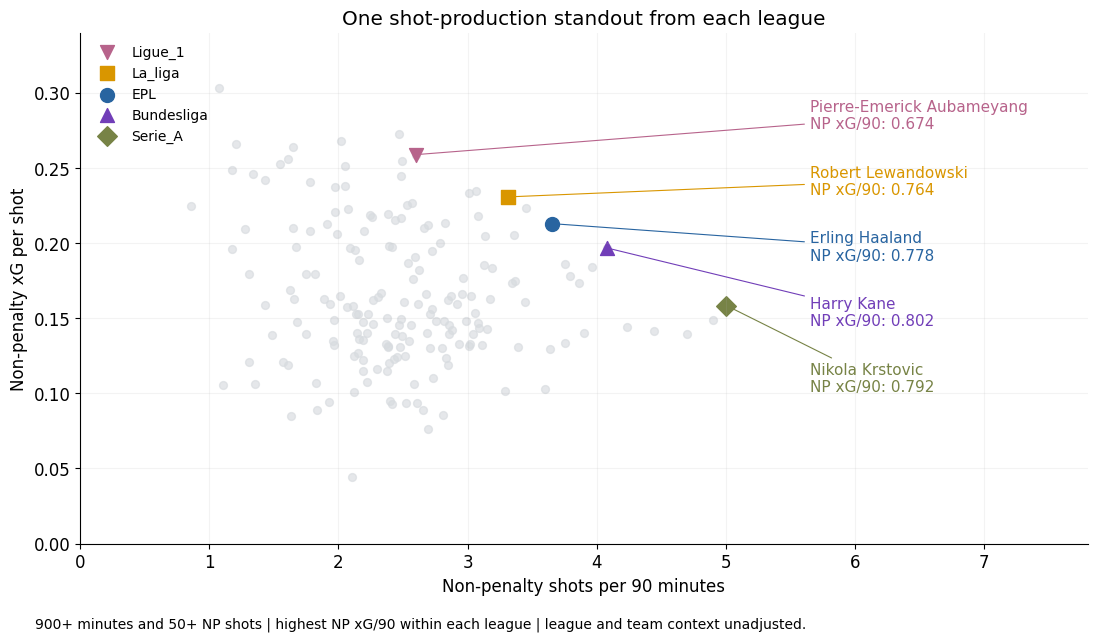

In [13]:
# NP xG/90 = NP shots/90 × NP xG/shot. Select the highest existing metric; do not invent a composite ability score.
league_pool = profiles.loc[profiles.non_penalty_shots.ge(STANDOUT_MIN_SHOTS)].copy()
league_pool["league_npxg90_rank"] = league_pool.groupby("league").npxg_per90.rank(method="min", ascending=False).astype(int)
# A tie for first is resolved by more minutes, then player_id for reproducibility. The full ranking preserves all ties.
league_representatives = league_pool.sort_values(["league", "npxg_per90", "minutes", "player_id"],
    ascending=[True, False, False, True]).groupby("league", sort=False).head(1).copy()
league_representatives = league_representatives.set_index("league").loc[LEAGUES].reset_index()
league_columns = [*KEY, "player_name", "team", "minutes", "non_penalty_shots", "npshots_per90", "npxg_per_shot", "npxg_per90", "league_npxg90_rank"]
assert len(league_representatives) == len(LEAGUES) and league_representatives.league.is_unique
assert league_representatives.league_npxg90_rank.eq(1).all()
assert np.allclose(league_representatives.npxg_per90, league_representatives.npshots_per90 * league_representatives.npxg_per_shot)
league_representatives[league_columns].to_csv(OUTPUT / "league_metric_representatives.csv", index=False, encoding="utf-8-sig")
league_pool[league_columns].sort_values(["league", "league_npxg90_rank", "player_id"]).to_csv(
    OUTPUT / "league_npxg90_ranking.csv", index=False, encoding="utf-8-sig")
league_selection = {"metric": "npxg_per90", "formula": "npshots_per90 * npxg_per_shot", "minimum_minutes": MIN_MINUTES,
    "minimum_np_shots": STANDOUT_MIN_SHOTS, "selection": "maximum within each league", "tie_break": "minutes descending, player_id ascending",
    "difference_from_global_standouts": "Does not require both metrics to exceed the pooled Q75 thresholds.",
    "players": league_representatives[league_columns].to_dict(orient="records"),
    "limits": "Within-cohort expected shot production, not overall ability, chance creation for teammates or league-adjusted quality."}
(OUTPUT / "league_representative_selection.json").write_text(json.dumps(league_selection, indent=2, ensure_ascii=False), encoding="utf-8")
print(text("One expected-shot-production representative per league:", "리그별 기대 슈팅 생산량 대표 1명:"))
print(league_representatives[["league", "player_name", "npshots_per90", "npxg_per_shot", "npxg_per90"]].round(3).to_string(index=False))
fig, ax = plt.subplots(figsize=(13, 7))
ax.scatter(profiles.npshots_per90, profiles.npxg_per_shot, color="#D7DBDF", s=32, alpha=0.65)
label_rows = league_representatives.sort_values("npxg_per_shot", ascending=False)
for y, (_, row) in zip(np.linspace(0.285, 0.11, len(label_rows)), label_rows.iterrows()):
    ax.scatter(row.npshots_per90, row.npxg_per_shot, color=COLORS[row.league], marker=MARKERS[row.league], s=100, label=row.league)
    ax.annotate(f"{row.player_name}\nNP xG/90: {row.npxg_per90:.3f}", xy=(row.npshots_per90, row.npxg_per_shot),
                xytext=(5.65,y), fontsize=11, color=COLORS[row.league], va="center",
                arrowprops={"arrowstyle":"-", "color":COLORS[row.league], "lw":0.8})
ax.set(xlim=(0, 7.8), ylim=(0, 0.34), xlabel=text("Non-penalty shots per 90 minutes", "90분당 비페널티 슈팅 수"),
       ylabel=text("Non-penalty xG per shot", "비페널티 슈팅당 xG"),
       title=text("One shot-production standout from each league", "리그별 기대 슈팅 생산량 대표 선수"))
ax.legend(loc="upper left", frameon=False, fontsize=10);ax.grid(alpha=0.15)
fig.text(0.09,0.03,text("900+ minutes and 50+ NP shots | highest NP xG/90 within each league | league and team context unadjusted.",
                       "900분·비페널티 슈팅 50회 이상 | 리그별 비페널티 xG/90분 최고 선수 | 팀·리그 환경을 보정하지 않았습니다."),fontsize=10)
fig.subplots_adjust(bottom=0.15)
save_chart(fig,"08_league_metric_representatives")

### 14. Name the players highlighted in the shot-profile scatter

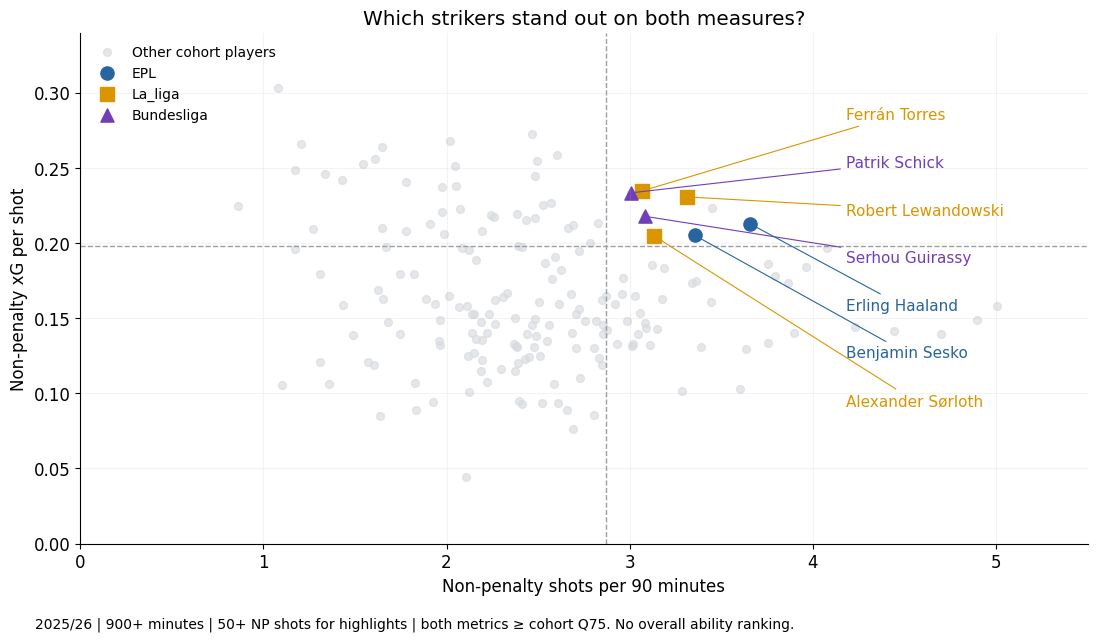

In [14]:
# Grey points retain cohort context. Colored points and labels identify every player who passes both thresholds.
fig, ax = plt.subplots(figsize=(13, 7))
ax.scatter(profiles.npshots_per90, profiles.npxg_per_shot, color="#D7DBDF", s=32, alpha=0.65, label=text("Other cohort players", "나머지 분석 대상"))
ax.axvline(volume_q75, color="#9B9FA4", linestyle="--", linewidth=1)
ax.axhline(quality_q75, color="#9B9FA4", linestyle="--", linewidth=1)
for league in LEAGUES:
    group = both_strong.loc[both_strong.league.eq(league)]
    if not group.empty:
        ax.scatter(group.npshots_per90, group.npxg_per_shot, color=COLORS[league], marker=MARKERS[league], s=90, label=league)
# Separate labels into an ordered right-hand column so clustered dots remain readable.
label_rows = both_strong.sort_values(["npxg_per_shot", *KEY], ascending=[False, True, True, True])
for y, (_, row) in zip(np.linspace(0.285, 0.095, len(label_rows)), label_rows.iterrows()):
    ax.annotate(row.player_name, xy=(row.npshots_per90, row.npxg_per_shot), xytext=(4.18, y),
                fontsize=11, color=COLORS[row.league], va="center",
                arrowprops={"arrowstyle": "-", "color": COLORS[row.league], "lw": 0.8})
ax.set(xlim=(0, max(5.5, profiles.npshots_per90.max()+0.2)), ylim=(0, 0.34),
       xlabel=text("Non-penalty shots per 90 minutes", "90분당 비페널티 슈팅 수"),
       ylabel=text("Non-penalty xG per shot", "비페널티 슈팅당 xG"),
       title=text("Which strikers stand out on both measures?", "슈팅 빈도와 기회 질이 함께 높은 선수는?"))
ax.legend(loc="upper left", frameon=False, fontsize=10)
ax.grid(alpha=0.15)
fig.text(0.09, 0.03, text("2025/26 | 900+ minutes | 50+ NP shots for highlights | both metrics ≥ cohort Q75. No overall ability ranking.",
                         "2025/26 | 900분 이상 | 강조 선수는 비페널티 슈팅 50회 이상 | 두 지표 모두 전체 대상 상위 25%. 종합 능력 순위가 아닙니다."), fontsize=10)
fig.subplots_adjust(bottom=0.15)
save_chart(fig, "06_both_measures_standouts")

### 15. Highlight observed goals above xG on the conversion scatter

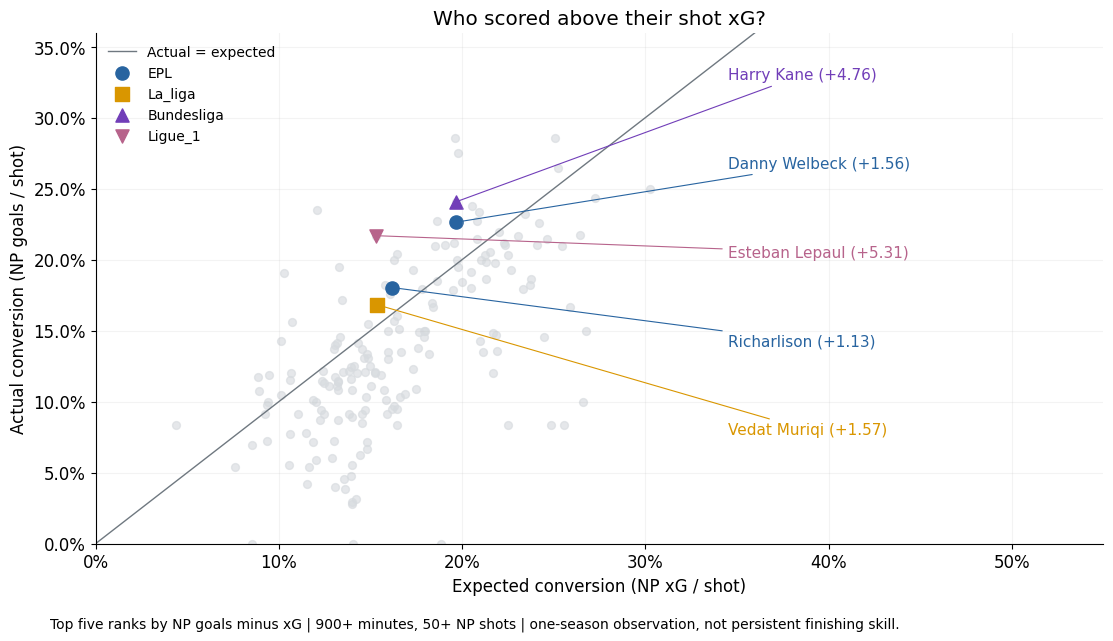

In [15]:
# Select the five highest ranks by NP goals minus shot xG, keeping boundary ties. Axes still show rates, labels show the count gap.
finishing_highlights = finishing_ranking.loc[finishing_ranking.metric_rank.le(5)].copy()
fig, ax = plt.subplots(figsize=(13, 7))
ax.scatter(profiles.expected_conversion_pct/100, profiles.conversion_pct/100, color="#D7DBDF", s=32, alpha=0.65)
ax.plot([0, 0.4], [0, 0.4], color="#6F7880", lw=1, label=text("Actual = expected", "실제 = 기대"))
for league in LEAGUES:
    group = finishing_highlights.loc[finishing_highlights.league.eq(league)]
    if not group.empty:
        ax.scatter(group.npxg_per_shot, group.conversion_pct/100, color=COLORS[league], marker=MARKERS[league], s=90, label=league)
label_rows = finishing_highlights.sort_values(["conversion_pct", *KEY], ascending=[False, True, True, True])
for y, (_, row) in zip(np.linspace(0.33, 0.08, len(label_rows)), label_rows.iterrows()):
    ax.annotate(f"{row.player_name} ({row.goals_minus_npxg:+.2f})", xy=(row.npxg_per_shot, row.conversion_pct/100), xytext=(0.345, y),
                fontsize=11, color=COLORS[row.league], va="center",
                arrowprops={"arrowstyle": "-", "color": COLORS[row.league], "lw": 0.8})
ax.set(xlim=(0, 0.55), ylim=(0, max(0.36, profiles.conversion_pct.max()/100+0.03)),
       xlabel=text("Expected conversion (NP xG / shot)", "기대 전환율(비페널티 슈팅당 xG)"),
       ylabel=text("Actual conversion (NP goals / shot)", "실제 전환율(비페널티 골 ÷ 슈팅)"),
       title=text("Who scored above their shot xG?", "슛의 xG보다 많은 골을 넣은 선수는?"))
ax.xaxis.set_major_formatter(PercentFormatter(1)); ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend(loc="upper left", frameon=False, fontsize=10); ax.grid(alpha=0.15)
fig.text(0.09, 0.03, text("Top five ranks by NP goals minus xG | 900+ minutes, 50+ NP shots | one-season observation, not persistent finishing skill.",
                         "비페널티 골−xG 상위 5위(동률 포함) | 900분·50회 슈팅 이상 | 한 시즌 관측이며 지속적인 결정력을 입증하지 않습니다."), fontsize=10)
fig.subplots_adjust(bottom=0.15)
save_chart(fig, "07_finishing_standouts")

### 16. Save tables and evidence

Save unrounded calculation tables, hashes, definitions and descriptive findings. Use rounded values only for presentation.

In [16]:
# Save unrounded calculation tables, hashes, definitions and descriptive findings. Use rounded values only for presentation.
profiles.to_csv(OUTPUT / "player_profiles.csv", index=False, encoding="utf-8-sig")
summary.to_csv(OUTPUT / "league_summary.csv", encoding="utf-8-sig")
representatives[comparison_columns].to_csv(OUTPUT / "representative_players.csv", index=False, encoding="utf-8-sig")
consistency.to_csv(OUTPUT / "match_consistency.csv", index=False, encoding="utf-8-sig")
match_profiles.to_csv(OUTPUT / "player_match_analysis.csv", index=False, encoding="utf-8-sig")
sensitivity.to_csv(OUTPUT / "minutes_sensitivity.csv", index=False, encoding="utf-8-sig")
manifest = json.loads((ROOT / "data/input_manifest.json").read_text(encoding="utf-8"))
for item in manifest["files"]:
    assert hashlib.sha256((DATA / item["file"]).read_bytes()).hexdigest() == item["sha256"]
validation = {"status": "pass", "season": "2025/26", "snapshot_date": "2026-10-03", "language": LANGUAGE,
    "profiles": len(profiles), "unique_players": int(profiles.player_id.nunique()),
    "appearances": len(cohort_matches), "shot_events": len(cohort_shots), "non_penalty_shots": len(np_shots),
    "parameters": {"min_minutes": MIN_MINUTES, "representative_min_np_shots": REP_MIN_SHOTS, "standout_min_np_shots": STANDOUT_MIN_SHOTS, "standout_quantile": STANDOUT_QUANTILE},
    "date_range": [str(cohort_matches.date.min()), str(cohort_matches.date.max())],
    "checks": ["unique keys", "scope", "required values", "metric formulas", "event-appearance joins",
               "event/profile reconciliation", "appearance totals", "zero-shot coverage", "composition totals",
               "900-minute cohort reproduction", "input hashes", "metric ranking order", "standout thresholds and shot sample"],
    "input_manifest": manifest,
    "versions": {"python": sys.version.split()[0], "pandas": pd.__version__, "numpy": np.__version__,
                 "matplotlib": __import__("matplotlib").__version__},
    "limits": "Saved provider snapshot only; no live source verification or opponent/team-context adjustment."}
(OUTPUT / "validation.json").write_text(json.dumps(validation, indent=2, ensure_ascii=False), encoding="utf-8")
findings = {"players": len(profiles), "median_np_shots_per90": float(median_volume),
    "median_npxg_per_shot": float(median_quality),
    "profile_group_counts": {str(k): int(v) for k,v in profiles.groupby("profile_group").size().items()},
    "representative_players": representatives[comparison_columns].to_dict(orient="records")}
(OUTPUT / "findings.json").write_text(json.dumps(findings, indent=2, ensure_ascii=False), encoding="utf-8")
print(text("Saved charts, tables and validation:", "차트·표·검증 기록 저장 완료:"), OUTPUT)
print(text("Median NP shots/90 and xG/shot:", "중앙값: 90분당 비페널티 슈팅·슈팅당 xG:"), round(median_volume, 3), round(median_quality, 3))

Saved charts, tables and validation: football/big-five-striker-profiles/analysis/results/en/20261004T165302398283Z
Median NP shots/90 and xG/shot: 2.465 0.158


## Checks and interpretation

The validation cell stops if counts or metrics disagree. Review printed medians and example tables before writing findings. Above-diagonal conversion is a one-season observation, not proof of persistent finishing skill. Match xG varies with minutes and match context.

## Next steps
Use charts 01–05 and saved comparison tables in the PowerPoint outline. Explain one comparison per slide. Review video/context before making tactical or recruitment claims.